# Core Sim

In [6]:
# EML26_core.py
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d

def run_simulation(csv_path, target_height=236.22, theta0=90, lrod_h=1.8288, base_wind=4.47, step=0.001, run_until="Recovery Deployment"):
    ########### INPUTS #################
    # theta0 == Launch angle (deg)
    # lrod_h == Launch rod height (m)
    # base_wind == 4.47 # At y=10m (m/s)
    wind_shear_exponent = 1/7
    elevation = 183 # m

    # SIMULATION CONTROL
    # run_until == "Apogee", "Recovery Deployment", "Landing", and {sec} Options | WARNING: DESCENT SIM NOT ACCURATE
    # step == Simulation resolution
    return_step = 0.01  # Returned data resolution

    # GENERAL CONSTANTS
    mass_earth = 5.97216786735e24 # kg
    radius_earth = 6378137 # m
    G_newt = 6.67430e-11 # Newton's gravitational constant
    g = 9.81 # m/s^2
    e = np.e
    rho_0 = 1.225  # kg/m³ (air density at sea level)
    L = 0.0065  # K/m (temperature lapse rate)
    T_0 = 288.15  # K (temperature at sea level)
    M = 0.0289644  # kg/mol (molar mass of Earth's air)
    R = 8.31447  # J/mol·K (universal gas constant)

    ######### IMPORT OPENROCKET DATA (ORI=OPENROCKET IMPORT) #############
    # Detect if running in Google Colab
    if 'google.colab' in sys.modules:
        # Path inside Colab's file system
        csv_path = "/content/ORI.csv"
    else:
        # Local path for VS Code
        csv_path = "~/Downloads/ORI.csv"

    # Pathlib validates whichever path was chosen
    csv_file = Path(csv_path).expanduser()
    if not csv_file.is_file():
        raise FileNotFoundError(f"CSV file not found: {csv_file}")

    ori = pd.read_csv(csv_file)

    # Find apogee
    if 'Vertical velocity (m/s)' not in ori.columns:
        raise ValueError("The selected CSV is missing the required 'Vertical velocity (m/s)' column.")

    apogee_mask = ori['Vertical velocity (m/s)'] < 0
    if apogee_mask.any():
        apogee_index = apogee_mask.idxmax()
    else:
        apogee_index = len(ori) - 1

    # Find parachute Cd
    avg_pre_dep_cd = np.mean(ori['Drag coefficient (​)'].loc[:apogee_index])
    chute_mask = ori['Drag coefficient (​)'] > 5 * avg_pre_dep_cd
    if chute_mask.any():
        chute_dep_index = chute_mask.idxmax()
        recovery_cd = np.mean(ori['Drag coefficient (​)'].loc[chute_dep_index:])
        chute_dep_t = ori.iat[max(chute_dep_index - 1, 0), 0]
    else:
        chute_dep_index = len(ori) - 1
        recovery_cd = avg_pre_dep_cd
        chute_dep_t = ori.iat[max(len(ori) - 1, 0), 0]

    # Delete data after apogee (useless)
    ori = ori.loc[:apogee_index]

    # Convert aoa from deg to rad
    ori['Angle of attack (°)'] = ori['Angle of attack (°)'] * np.pi/180

    # Find A_rocket
    A_rocket = ori.at[1, 'Reference area (cm²)'] / 10000 # cm^2 to m^2

    # Find t_burn
    thrust_series = ori['Thrust (N)']
    burn_mask = thrust_series.iloc[5:] == 0
    if burn_mask.any():
        t_burn_index = burn_mask.idxmax()
        t_burn = ori.iat[t_burn_index, 0]
    else:
        t_burn = ori.iat[max(len(ori) - 1, 0), 0]

    # Mass interpolation
    mass_data = interp1d(ori['# Time (s)'], ori['Mass (g)'] / 1000, kind="linear", fill_value="extrapolate")
    interpolated_times = np.arange(ori['# Time (s)'].min(), ori['# Time (s)'].max(), step)  # Sim time step
    interpolated_mass = mass_data(interpolated_times)
    masses = pd.DataFrame({"t": interpolated_times, "m": interpolated_mass})

    # Thrust interpolation
    F_thrust = interp1d(ori['# Time (s)'], ori['Thrust (N)'], kind="linear", fill_value="extrapolate")
    interpolated_thrust = F_thrust(interpolated_times)
    thrusts = pd.DataFrame({"t": interpolated_times, "N": interpolated_thrust})

    # Get Cd (could do cd based on reynolds number later (Re is based on vel))
    Cd_avg = np.mean(ori['Drag coefficient (\u200b)'])

    # Axial Cd interpolation
    raw_Cd_a_data = interp1d(ori['Angle of attack (°)'], ori['Axial drag coefficient (\u200b)'], kind="linear", fill_value="extrapolate")
    interpolated_aoas = np.arange(ori['Angle of attack (°)'].min(), ori['Angle of attack (°)'].max(), 0.001)
    interpolated_Cd_a = raw_Cd_a_data(interpolated_aoas)
    Cd_a_data = pd.DataFrame({"aoa": interpolated_aoas, "Cd_a": interpolated_Cd_a})

    # Normal Force Coefficient (Cn) interpolation
    raw_Cn_data = interp1d(ori['Angle of attack (°)'], ori['Normal force coefficient (​)'], kind="linear", fill_value="extrapolate")
    interpolated_Cn = raw_Cn_data(interpolated_aoas)
    Cn_data = pd.DataFrame({"aoa": interpolated_aoas, "Cn": interpolated_Cn})

    # Cg interpolation
    raw_Cg_data = interp1d(ori['# Time (s)'], ori['CG location (cm)'] / 100, kind="linear", fill_value="extrapolate")
    interpolated_Cg = raw_Cg_data(interpolated_times)
    Cg_data = pd.DataFrame({"t": interpolated_times, "Cg": interpolated_Cg})

    # Cp interpolation
    raw_Cp_data = interp1d(ori['Angle of attack (°)'], ori['CP location (cm)'] / 100, kind="linear", fill_value="extrapolate")
    interpolated_Cp = raw_Cp_data(interpolated_aoas)
    Cp_data = pd.DataFrame({"aoa": interpolated_aoas, "Cp": interpolated_Cp})

    # I_z interpolation
    raw_Iz_data = interp1d(ori['# Time (s)'], ori['Rotational moment of inertia (kg·m²)'], kind="linear", fill_value="extrapolate")
    interpolated_Iz = raw_Iz_data(interpolated_times)
    Iz_data = pd.DataFrame({"t": interpolated_times, "Iz": interpolated_Iz})

    # Theta Damping Coefficient interpolation
    raw_pdc_data = interp1d(ori['Angle of attack (°)'], ori['Pitch damping coefficient (​)'], kind="linear", fill_value="extrapolate")
    interpolated_pdc = raw_pdc_data(interpolated_aoas)
    pdc_data = pd.DataFrame({"aoa": interpolated_aoas, "pdc": interpolated_pdc})

    ori_max_aoa = np.max(interpolated_aoas)
    ori_max_t = np.max(ori['# Time (s)'])
    ori = pd.read_csv(csv_file)
    ################################################################################
    # DEFINE FUNCTIONS

    # Thrust function
    def thrust(t):
        if t <= t_burn:
            return np.interp(t, thrusts["t"], thrusts["N"])
        else:
            return 0

    # Adjusted Drag Force with Angle using Cd_data
    def rho(y):
        return rho_0 * (1 - L * (y+elevation) / T_0) ** 4.25588

    def Cd(v): # (Later, get cd vs aoa from OpenRocket)
        return Cd_avg

    def drag(v, y, theta):
        Cd_value = Cd(v)
        air_density = rho(y)
        drag_force = 0.5 * Cd_value * air_density * v**2 * A_rocket
        return drag_force

    # Mass as a function of time
    def mass(t):
        if t <= t_burn:
            return np.interp(t, masses["t"], masses["m"])
        else:
            return np.interp(t_burn, masses["t"], masses["m"])

    # Wind speed function
    def wind_speed(y):
        if y > lrod_h:
            return base_wind * ((y / 10)**wind_shear_exponent)
        else:
            return 0

    # Weathercocking angle calculation
    def weathercocking(v, y):
        if y > lrod_h:
            W = wind_speed(y)
            if W > 0:
                wind_effect = np.arctan(v / W)
                return theta0 - (np.pi / 2) + wind_effect
            else:
                return theta0
        else:
            return theta0

    # Flight path angle calculation
    def gamma_calc(vy, vx):
        if np.hypot(vx, vy) <= 1e-9:
            gamma = theta
        else:
            gamma = np.arctan2(vy,vx)
        return gamma

    # Normal Force Coefficient calculation
    def Cn(aoa):
        aoa_clamped = np.clip(aoa, Cn_data["aoa"].min(), Cn_data["aoa"].max())
        return np.interp(aoa_clamped, Cn_data["aoa"], Cn_data["Cn"])

    # Normal Force calculation
    def Fn(v, y, aoa):
        Cn_value = Cn(aoa)
        air_density = rho(y)
        normal_force = 0.5 * Cn_value * air_density * v**2 * A_rocket
        return normal_force

    # Axial Drag Coefficient calculation
    def cda(aoa):
        if t <= chute_dep_t:
            aoa_clamped = np.clip(aoa, Cd_a_data["aoa"].min(), Cd_a_data["Cd_a"].max())
            return np.interp(aoa_clamped, Cd_a_data["aoa"], Cd_a_data["Cd_a"])
        else:
            return recovery_cd

    # Cg calculation
    def locate_Cg(t):
        if t <= ori_max_t:
            return np.interp(t, Cg_data["t"], Cg_data["Cg"])
        else:
            return np.interp(ori_max_t, Cg_data["t"], Cg_data["Cg"])

    # Cp calculation
    def locate_Cp(aoa, brake_angle=0):
        if t <= chute_dep_t:
            if brake_angle == 0:
                aoa_clamped = np.clip(aoa, Cp_data["aoa"].min(), Cp_data["Cp"].max())
                return np.interp(aoa_clamped, Cp_data["aoa"], Cp_data["Cp"])
            else:
                return 0.442 # temporary: do CFD to find Cp dif and then apply that dif based on brake area function
        else:
            return Cp_data["Cp"].min()

    # Iz calculation
    def Iz(t):
        if t <= ori_max_t:
            return np.interp(t, Iz_data["t"], Iz_data["Iz"])
        else:
            return np.interp(ori_max_t, Iz_data["t"], Iz_data["Iz"])

    # PDC calculation
    def pdc(aoa):
        if aoa <= ori_max_aoa:
            return np.interp(aoa, pdc_data["aoa"], pdc_data["pdc"])
        else:
            return np.interp(ori_max_aoa, pdc_data["aoa"], pdc_data["pdc"])

    # Simulation end point
    def run_condition():
        if run_until == "Apogee":
            return vy >= 0
        elif run_until == "Landing":
            return y >= 0
        elif isinstance(run_until, (int, float)):
            return t <= run_until
        else: # Defaults to until recovery deployment
            return t <= chute_dep_t

    ############## RUN COMPUTATION #####################
    results = []
    results.clear()
    global t, v, y, x  # Ensure function modifies global variables
    y = 0  # Reference altitude for windspeed (m)
    x = 0  # Horizontal position (m)
    vx = 0  # Initial x-velocity (m/s)
    vy = 0  # Initial y-velocity (m/s)
    v = 0 # Initial velocity (m/s)
    flight_time = 0
    vx_apparent = 0 # Initial x-velocity relative to air (m/s)
    vy_apparent = 0 # Initial y-velocity relative to air (m/s)
    v_apparent = 0 # Initial velocity relative to air (m/s)
    ax = 0 # Initial x-acceleration (m/s^2)
    ay = 0 # Initial y-acceleration (m/s^2)
    a = 0
    theta = theta0 * np.pi/180 # Initial pitch (rad)
    gamma = np.pi/2 # Initial flight path angle (rad)
    t = 0  # Initial launch time (s)
    apogee = 0 # Initial apogee (m)
    torque = 0 # Nm
    a_ang = 0 # kgm
    v_ang = 0 # rad/s
    v_axial = 0 # m/s

    # Run sim
    while run_condition():
        # === 1. KINEMATIC STATE UPDATES ===
        W_s = wind_speed(y)
        vx_apparent = vx - W_s
        vy_apparent = vy
        v = np.hypot(vx, vy)
        v_apparent = np.hypot(vx_apparent, vy_apparent)

        # Apogee deadband protection
        if v_apparent > 0.1:
            gamma = np.arctan2(vy_apparent, vx_apparent)
            aoa = theta - gamma
        else:
            # If the air is practically stationary, it cannot force an angle of attack
            gamma = theta
            aoa = 0.0

        # Ensure aoa wraps strictly between -pi and +pi to stop out-of-bounds flipping
        aoa = np.arctan2(np.sin(aoa), np.cos(aoa))

        # === 2. COEFFICIENT LOOKUPS & FORCES ===
        C_d = Cd(v)
        m = mass(t)
        F_t = thrust(t)

        F_n = Fn(v_apparent, y, aoa)
        C_g = locate_Cg(t)
        C_p = locate_Cp(aoa, 0)
        stab_margin = np.abs(C_p - C_g)

        torque = -np.sign(aoa) * np.abs(F_n) * stab_margin
        damping_torque = -np.abs(pdc(aoa)) * v_ang
        I_z = Iz(t)

        Fn_x = -F_n * np.sin(theta)
        Fn_y = F_n * np.cos(theta)

        C_da = cda(aoa)
        v_axial = v_apparent * np.cos(aoa)
        F_axial_drag = 0.5 * C_da * rho(y) * (v_axial**2) * A_rocket

        # === 3. GROUND / RAIL HANDLING ===
        if y <= 0:
            if F_t <= m * g:  # Not enough thrust to lift off
                ay, ax, vy, vx, v_ang, a_ang = 0, 0, 0, 0, 0, 0
                t += step
                continue

        # === 4. RIGID BODY DYNAMICS ===
        # Translational integration
        ay = (F_t * np.sin(theta) - F_axial_drag * np.sin(gamma) + Fn_y - m * g) / m
        ax = (F_t * np.cos(theta) - F_axial_drag * np.cos(gamma) + Fn_x) / m

        vy += ay * step
        vx += ax * step
        y += vy * step
        x += vx * step

        # Rotational integration
        a_ang = (torque + damping_torque) / I_z
        v_ang += a_ang * step
        theta += v_ang * step

        # === 5. BOUNDARY LOCK & TERMINATION ===
        if y < 0:
            y, vx, vy, v_ang, a_ang = 0, 0, 0, 0, 0
            # If it's after motor burnout and hits 0, the flight is finished
            if t > t_burn:
                break

        t += step

        # Append results as a row
        results.append([t, F_t, np.degrees(theta), np.degrees(gamma), np.degrees(aoa), ax, ay, vx, vy, y, x, m, C_d, F_axial_drag, W_s])

        # Update apogee
        if y > apogee:
            apogee = y

        # Debug checks (removed 'or y < 0' since it's safely handled above)
        if np.isnan(v) or np.isnan(y):
            break
    # Convert results to DataFrame after the loop
    df = pd.DataFrame(results, columns=[
        'time (s)', 'thrust (N)','Pitch (°)', 'Flight Path Angle (°)', 'AoA (°)', 'ax', 'ay',
        'x velocity (m/s)', 'y velocity (m/s)', 'altitude (m)', 'horizontal displacement (m)',
        'mass (kg)', 'Cd', 'Fd (N)', 'W (m/s)'
    ])

    if not df.empty:
        flight_time = float(df['time (s)'].max())

    return apogee, flight_time, df, chute_dep_t if flight_time >= chute_dep_t else None

# Google Colab Only Plotter

apogee: 279.20 m
flight time: 9.5 s


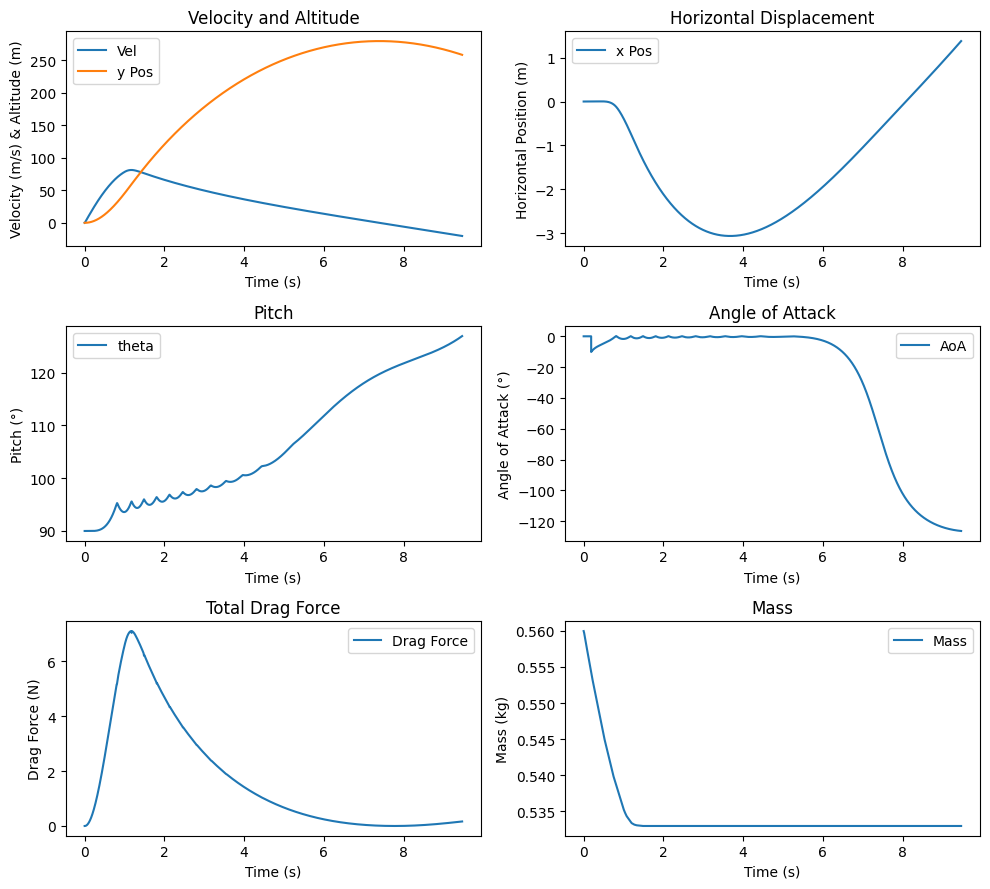

In [11]:
apogee, flight_time, df, chute_dep_t = run_simulation("ORI", target_height=236.22, theta0=90, lrod_h=1.8288, base_wind=4.47, step=0.001, run_until="Recovery Deployment")

print(f"apogee: {apogee:.2f} m")
print(f"flight time: {flight_time:.1f} s")

# Plot results
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, figsize=(10, 9))

# Plot velocity and altitude
ax[0, 0].plot(df['time (s)'], df['y velocity (m/s)'], label="Vel")
ax[0, 0].plot(df['time (s)'], df['altitude (m)'], label="y Pos")
ax[0, 0].set_title("Velocity and Altitude")
ax[0, 0].set_xlabel("Time (s)")
ax[0, 0].set_ylabel("Velocity (m/s) & Altitude (m)")
ax[0, 0].legend()

# Plot horizontal position
ax[0, 1].plot(df['time (s)'], df['horizontal displacement (m)'], label="x Pos")
ax[0, 1].set_title("Horizontal Displacement")
ax[0, 1].set_xlabel("Time (s)")
ax[0, 1].set_ylabel("Horizontal Position (m)")
ax[0, 1].legend()

# Plot theta
ax[1, 0].plot(df['time (s)'], df['Pitch (°)'], label="theta")
ax[1, 0].set_title("Pitch")
ax[1, 0].set_xlabel("Time (s)")
ax[1, 0].set_ylabel("Pitch (°)")
ax[1, 0].legend()

# Plot AoA
ax[1, 1].plot(df['time (s)'], df['AoA (°)'], label="AoA")
ax[1, 1].set_title("Angle of Attack")
ax[1, 1].set_xlabel("Time (s)")
ax[1, 1].set_ylabel("Angle of Attack (°)")
ax[1, 1].legend()

# Plot drag
ax[2, 0].plot(df['time (s)'], df['Fd (N)'], label="Drag Force")
ax[2, 0].set_title("Total Drag Force")
ax[2, 0].set_xlabel("Time (s)")
ax[2, 0].set_ylabel("Drag Force (N)")
ax[2, 0].legend()

# Plot mass
ax[2, 1].plot(df['time (s)'], df['mass (kg)'], label="Mass")
ax[2, 1].set_title("Mass")
ax[2, 1].set_xlabel("Time (s)")
ax[2, 1].set_ylabel("Mass (kg)")
ax[2, 1].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()